# Chapter 17 - Probability density estimation

*This notebook contains all the sample code in Chapter 17.*

## Outline

- [Introduction](#Introduction)
- [Nonparametric estimation](#Nonparametric)
    - [Histogram](#Histogram)
    - [Kernel density estimation](#Kernel)
    - [K-nearest-neighbor density estimation](#knn)
    - [The empirical distribution function](#Empirical)
- [Parametric estimation](#Parametric)
    - [Maximum-likelihood estimation](#MLE)
    - [Gaussian mixture models](#GMM)

## Introduction <a id="Introduction"></a>

In many applications, it is useful to estimate the probability distribution from which the available observations were generated. A density estimate can be used to visualize the structure of the data, detect unlikely observations, build generative models, or support probabilistic classification and decision making.

**Density estimation** is the problem of estimating an unknown *probability density function* (PDF) from a finite sample $\mathcal{X}=\left\{\mathbf{x}_1,\mathbf{x}_2,\ldots,\mathbf{x}_N\right\}$, whose observations are usually assumed to be *independent and identically distributed* (i.i.d.). 

Density-estimation methods can be broadly divided into two families:
- **Parametric methods**: the unknown density is assumed to belong to a family $f(\mathbf{x};\boldsymbol{\theta})$ described by a finite-dimensional parameter vector $\boldsymbol{\theta}$. The parameters are estimated from the data, commonly by maximum likelihood. Parametric methods are compact and statistically efficient when the assumed family is appropriate, but they can produce poor estimates when the model is misspecified.
- **Nonparametric methods**: no fixed finite-dimensional family is assumed. The complexity of the estimate may increase with the number of observations. These methods are more flexible, but their performance depends strongly on smoothing parameters and generally deteriorates as the dimensionality increases.

## Nonparametric estimation <a id="Nonparametric"></a>

### Histogram <a id="Histogram"></a>

The **histogram** is one of the simplest density estimators. The input axis is divided into non-overlapping intervals called **bins**. Given an origin $x_0$ and a bin width $h>0$, the bins are $[x_0+mh,\;x_0+(m+1)h)$, $m \in \mathbb{Z}$. 

For a point $x$, the histogram density estimate is:
$$
\widehat{f}(x) = \frac{\#\left\{x_n\text{ in the same bin as }x\right\}}{Nh}.
$$
The factor $Nh$ ensures that the total area of the histogram is one. Once the bin counts have been stored, the original observations are no longer needed to evaluate the estimate.

A closely related moving-window estimator places a bin of width $h$ around every query point:
$$
\widehat{f}(x) = \frac{1}{Nh} \sum_{n=1}^{N} w\!\left(\frac{x-x_n}{h}\right),
$$
where:
$
w(u) =
\begin{cases}
1, & |u|<1/2,\\
0, & \text{otherwise}.
\end{cases}
$
Unlike an ordinary fixed-bin histogram, this estimator does not require selecting a common bin origin. Nevertheless, its rectangular window still produces discontinuities.

NumPy returns both the estimated bin values and the bin edges. Setting `density=True` normalizes the histogram so that its integral is one:

Matplotlib can compute and display the normalized histogram directly:

The following example generates a *bimodal* scalar distribution by mixing two Gaussian populations. The term bimodal refers to the presence of two modes; it should not be confused with *bivariate*, which describes a distribution of two variables.

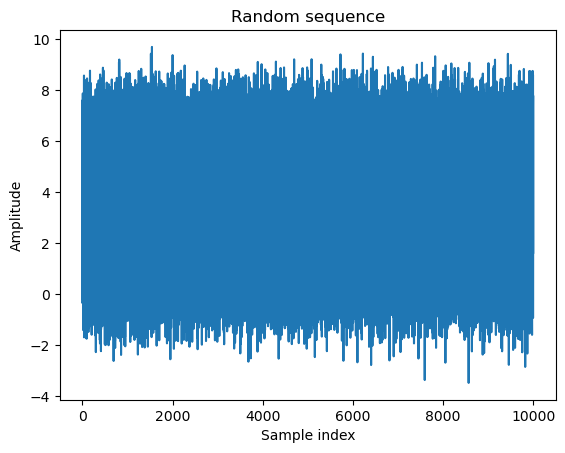

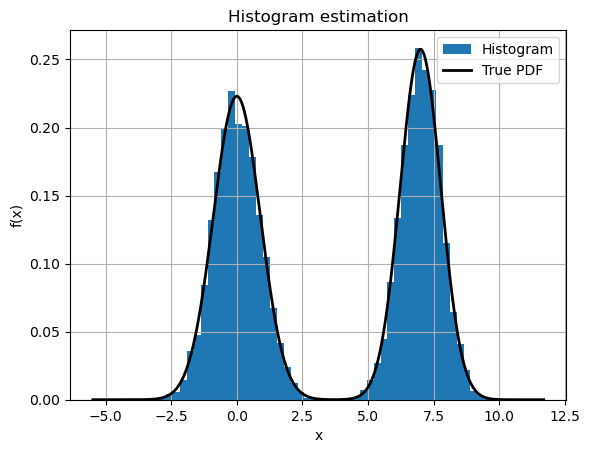

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

rng = np.random.default_rng(0)

N1, N2 = 5000, 5000
mean1, mean2 = 0.0, 7.0
var1, var2 = 0.8, 0.6
n_bins = 50

x1 = rng.normal(mean1, np.sqrt(var1), size=N1)
x2 = rng.normal(mean2, np.sqrt(var2), size=N2)
x = np.concatenate((x1, x2))
rng.shuffle(x)

plt.figure()
plt.plot(x)
plt.xlabel('Sample index')
plt.ylabel('Amplitude')
plt.title('Random sequence')

x_grid = np.linspace(x.min() - 2, x.max() + 2, 1000)
true_pdf = (
    (N1 / len(x)) * norm.pdf(x_grid, mean1, np.sqrt(var1))
    + (N2 / len(x)) * norm.pdf(x_grid, mean2, np.sqrt(var2))
)

plt.figure()
plt.hist(x, bins=n_bins, density=True, label='Histogram')
plt.plot(x_grid, true_pdf, 'k', lw=2, label='True PDF')
plt.grid()
plt.title('Histogram estimation')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()

### Kernel density estimation <a id="Kernel"></a>

A smoother estimate is obtained by replacing the previous rectangular window with a smooth **kernel** function. A kernel $K(u)$ is typically non-negative, symmetric, and normalized so that:
$$
\int_{-\infty}^{+\infty}K(u)\,du=1.
$$
The most common choice is the Gaussian kernel\index{Gaussian kernel}\index{Kernel!Gaussian}:
$$
K(u) = \frac{1}{\sqrt{2\pi}} \exp\!\left(-\frac{u^2}{2}\right).
$$
The **kernel density estimator** (KDE), also known as the *Parzen-window estimator*, is
$$
\widehat{f}_h(x) = \frac{1}{Nh} \sum_{n=1}^{N} K\!\left(\frac{x-x_n}{h}\right),
$$
where $h>0$ is the bandwidth.

Scikit-learn provides the `KernelDensity` estimator. Its `score_samples` method returns the log-density at each query point:

Text(0, 0.5, 'f(x)')

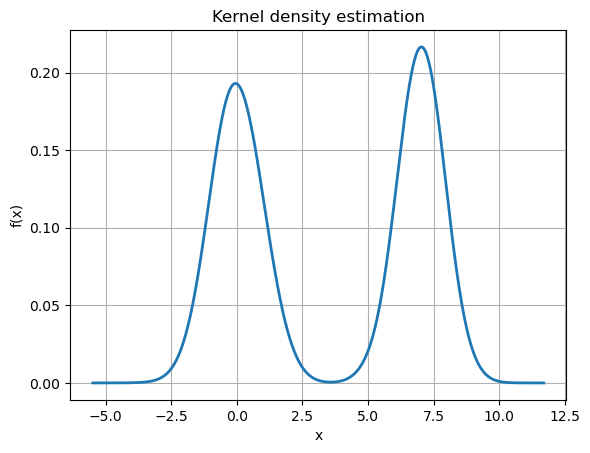

In [2]:
from sklearn.neighbors import KernelDensity

X = x.reshape(-1, 1)
x_grid_2d = x_grid.reshape(-1, 1)

kde = KernelDensity(kernel='gaussian', bandwidth=0.5)
kde.fit(X)

log_density = kde.score_samples(x_grid_2d)
pdf = np.exp(log_density)

plt.figure()
plt.plot(x_grid, pdf, lw=2)
plt.grid()
plt.title('Kernel density estimation')
plt.xlabel('x')
plt.ylabel('f(x)')

A practical way to select the bandwidth is to maximize the *cross-validated log-likelihood*:

In [3]:
from sklearn.model_selection import GridSearchCV

bandwidth_grid = np.logspace(-1.2, 0.8, 30)

# A subset keeps the illustrative search reasonably fast.
indices = rng.choice(len(X), size=2000, replace=False)
X_search = X[indices]

search = GridSearchCV(
    KernelDensity(kernel='gaussian'),
    param_grid={'bandwidth': bandwidth_grid},
    cv=5
)
search.fit(X_search)

selected_bandwidth = search.best_params_['bandwidth']
best_kde = KernelDensity(
    kernel='gaussian',
    bandwidth=selected_bandwidth
).fit(X)

print('Selected bandwidth:', selected_bandwidth)

Selected bandwidth: 0.22476264692201617


### K-nearest-neighbor density estimation <a id="knn"></a>

The **$k$-nearest-neighbor** (kNN) density estimator adapts its smoothing region to the local concentration of observations. Let $r_k(\mathbf{x})$ be the distance from a query point $\mathbf{x}\in\mathbb{R}^d$ to its $k$-th nearest training observation. A $d$-dimensional ball of radius $r_k(\mathbf{x})$ has volume $V_d\,r_k(\mathbf{x})^d$ with:
$$
V_d=\frac{\pi^{d/2}}{\Gamma(d/2+1)}.
$$
Since this ball contains approximately $k$ of the $N$ observations, the density estimate is:
$$
\widehat{f}(\mathbf{x}) = \frac{k} {N\,V_d\,r_k(\mathbf{x})^d}.
$$
For $d=1$, we have $V_1=2$, and therefore we obtain:
$$
\widehat{f}(x) = \frac{k}{2N\,r_k(x)}.
$$
A small $k$ produces a locally adaptive but highly variable estimate, whereas a large $k$ produces stronger smoothing. Unlike a conventional KDE, the basic kNN density estimator is not generally a globally normalized density and may exhibit problematic tails on unbounded domains. It is nevertheless useful as a local density or anomaly score.

The following implementation works for both scalar and multivariate observations:

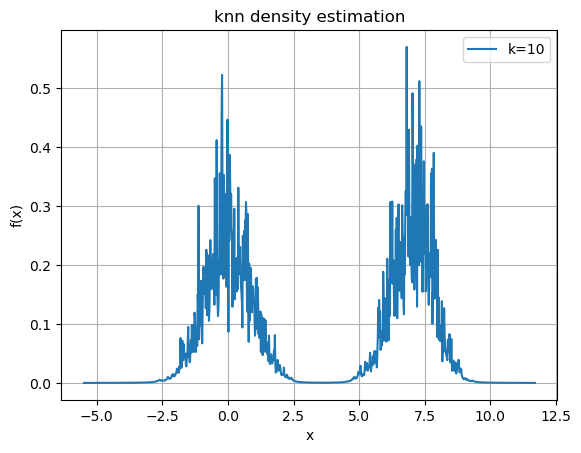

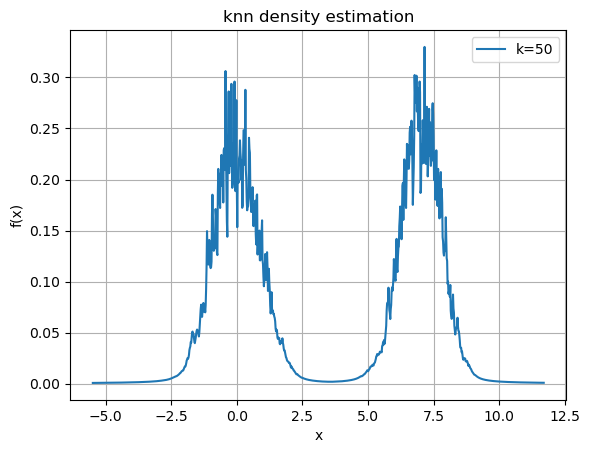

In [4]:
from math import gamma
from sklearn.neighbors import NearestNeighbors

def knn_density(X, X_query, k=10):
    X = np.asarray(X, dtype=float)
    X_query = np.asarray(X_query, dtype=float)

    if X.ndim == 1:
        X = X.reshape(-1, 1)
    if X_query.ndim == 1:
        X_query = X_query.reshape(-1, 1)

    neighbors = NearestNeighbors(n_neighbors=k)
    neighbors.fit(X)
    distances, _ = neighbors.kneighbors(X_query)

    radius = np.maximum(distances[:, -1], np.finfo(float).eps)
    d = X.shape[1]
    unit_ball_volume = np.pi ** (d / 2) / gamma(d / 2 + 1)

    return k / (len(X) * unit_ball_volume * radius ** d)


for k in (10, 50):
    density = knn_density(x, x_grid, k=k)
    plt.figure()
    plt.plot(x_grid, density, label=f'k={k}')
    plt.grid()
    plt.title('knn density estimation')
    plt.xlabel('x')
    plt.ylabel('f(x)')
    plt.legend()

### The empirical distribution function <a id="Empirical"></a>

Let $X$ be a scalar random variable with **cumulative distribution function** (CDF) $F(x)=P(X\leq x)$. Given $N$ observations $x_1,\ldots,x_N$, the ***empirical distribution function*** (EDF) is:
$$
\widehat{F}_N(x) = \frac{1}{N}\sum_{n=1}^{N}\mathbb{I}(x_n\leq x),
$$
where $\mathbb{I}(\cdot)$ is the indicator function. Thus, $\widehat{F}_N(x)$ is the fraction of observations not exceeding $x$.

A smooth approximation can be obtained by replacing the hard step with a *sigmoid*:
$$
S_\beta(t)=\frac{1}{1+\exp(-\beta t)},
$$
%
where $\beta>0$ controls the steepness. The smoothed empirical CDF and its derivative are:
$$
\widetilde{F}_{N,\beta}(x) = \frac{1}{N}\sum_{n=1}^{N}S_\beta(x-x_n),
$$
and
$$
\widetilde{f}_{N,\beta}(x) = \frac{\beta}{N} \sum_{n=1}^{N} S_\beta(x-x_n)\left[1-S_\beta(x-x_n)\right].
$$
This construction is equivalent to kernel density estimation with a logistic kernel. A numerically stable implementation is:

Text(0, 0.5, 'f(x)')

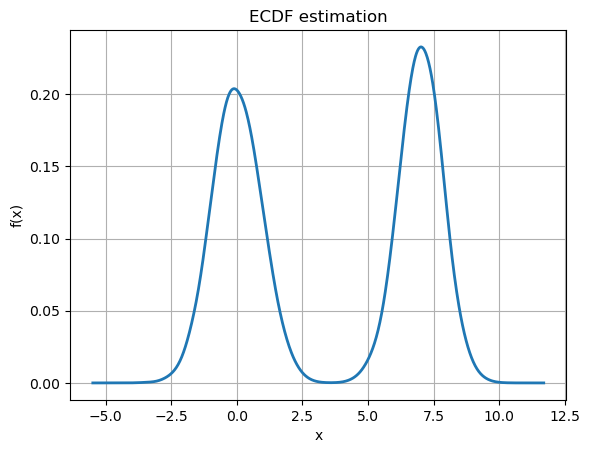

In [5]:
import numpy as np
from scipy.special import expit

def smooth_ecdf_density(samples, x_grid, beta=4.0):
    samples = np.asarray(samples, dtype=float).ravel()
    x_grid = np.asarray(x_grid, dtype=float).ravel()

    u = beta * (x_grid[:, None] - samples[None, :])
    sigmoid = expit(u)    # The logistic function

    cdf = np.mean(sigmoid, axis=1)
    pdf = beta * np.mean(sigmoid * (1.0 - sigmoid), axis=1)
    return cdf, pdf


_, pdf = smooth_ecdf_density(x, x_grid, beta=5)

plt.figure()
plt.plot(x_grid, pdf, lw=2)
plt.grid()
plt.title('ECDF estimation')
plt.xlabel('x')
plt.ylabel('f(x)')

## Parametric estimation <a id="Parametric"></a>

In parametric density estimation, the unknown distribution is assumed to belong to a family $f(\mathbf{x};\boldsymbol{\theta})$, where the finite-dimensional vector $\boldsymbol{\theta}$ contains the unknown model parameters. Estimation then reduces to learning $\boldsymbol{\theta}$ from the observations.

### Maximum-likelihood estimation <a id="MLE"></a>

For independent observations $\mathcal{X} = \left\{\mathbf{x}_1,\ldots,\mathbf{x}_N\right\}$, the **likelihood function** is:
$$
L(\boldsymbol{\theta};\mathcal{X}) = \prod_{n=1}^{N} p(\mathbf{x}_n;\boldsymbol{\theta}),
$$
while the **maximum-likelihood estimate** is:
$$
\widehat{\boldsymbol{\theta}}_{\mathrm{ML}} = \operatorname*{arg\,max}_{\boldsymbol{\theta}} L(\boldsymbol{\theta};\mathcal{X}).
$$
Because products of many probabilities can underflow numerically, the *log-likelihood* is normally optimized:
$$
\ell(\boldsymbol{\theta};\mathcal{X}) = \log L(\boldsymbol{\theta};\mathcal{X}) = \sum_{n=1}^{N} \log p(\mathbf{x}_n;\boldsymbol{\theta}).
$$
Since the logarithm is strictly increasing, maximizing $L$ and maximizing $\ell$ give the same solution.

Text(0, 0.5, 'f(x)')

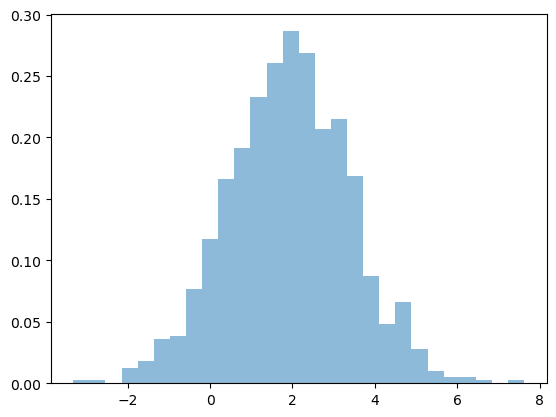

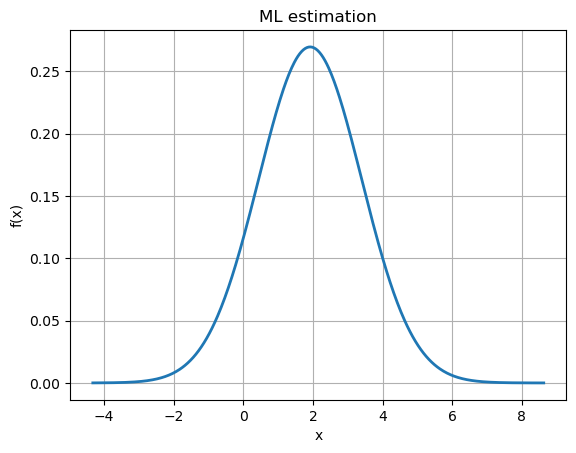

In [6]:
rng = np.random.default_rng(1)
x_gaussian = rng.normal(loc=2.0, scale=1.5, size=1000)

mean_hat = np.mean(x_gaussian)
variance_hat = np.var(x_gaussian, ddof=0)

grid = np.linspace(x_gaussian.min() - 1, x_gaussian.max() + 1, 500)
pdf_hat = norm.pdf(grid, loc=mean_hat, scale=np.sqrt(variance_hat))

plt.hist(x_gaussian, bins='fd', density=True, alpha=0.5)

plt.figure()
plt.plot(grid, pdf_hat, lw=2)
plt.grid()
plt.title('ML estimation')
plt.xlabel('x')
plt.ylabel('f(x)')

### Gaussian mixture models <a id="GMM"></a>

A single Gaussian distribution cannot adequately represent a multimodal density. A **Gaussian mixture model** (GMM) represents the density as a weighted sum of $M$ Gaussian components:
$$
f(\mathbf{x}) = \sum_{m=1}^{M} \alpha_m \mathcal{N}\!\left( \mathbf{x}; \boldsymbol{\mu}_m, \boldsymbol{\Sigma}_m \right),
$$
where:
$$
\alpha_m\geq0 \qquad \text{and} \qquad \sum_{m=1}^{M}\alpha_m=1.
$$
The parameters $\alpha_m$, $\boldsymbol{\mu}_m$, and $\boldsymbol{\Sigma}_m$ are respectively the mixture weight, mean vector, and covariance matrix of component $m$.

The mixture components are latent groups, not necessarily known semantic classes. Given an observation $\mathbf{x}_n$, the posterior probability that it was generated by component $m$, also called the *responsibility*, is:
$$
\gamma_{nm} = P(z_n=m\mid\mathbf{x}_n) = \frac{ \alpha_m \mathcal{N}(\mathbf{x}_n; \boldsymbol{\mu}_m, \boldsymbol{\Sigma}_m)}{
\sum_{j=1}^{M} \alpha_j \mathcal{N}( \mathbf{x}_n; \boldsymbol{\mu}_j, \boldsymbol{\Sigma}_j)}.
$$
The responsibilities are soft assignments and satisfy:
$$
\sum_{m=1}^{M}\gamma_{nm}=1,
$$
for every observation.

Direct maximization of the GMM likelihood is difficult because the component labels $z_n$ are unobserved. The **expectation-maximization** (EM) algorithm alternates between estimating the latent assignments and updating the model parameters.

We randomly initialize the mean and the variance estimates, and set the component distribution priors to $\widehat{\alpha}_1 = \ldots = \widehat{\alpha}_M = 1/M$. Then, given current parameter estimates, one EM iteration consists of:
1. **E-step**: compute the responsibilities:
$$
\gamma_{nm} = \frac{\alpha_m \mathcal{N}(\mathbf{x}_n; \boldsymbol{\mu}_m, \boldsymbol{\Sigma}_m)}{\sum_{j=1}^{M} \alpha_j \mathcal{N}(\mathbf{x}_n; 	\boldsymbol{\mu}_j,	\boldsymbol{\Sigma}_j)}.
$$
2. **M-step**: define
$$
N_m=\sum_{n=1}^{N}\gamma_{nm},
$$
and update:
$$
\alpha_m =	\frac{N_m}{N},
$$
$$
\boldsymbol{\mu}_m = \frac{1}{N_m} \sum_{n=1}^{N} \gamma_{nm}\mathbf{x}_n,
$$
$$
\boldsymbol{\Sigma}_m = \frac{1}{N_m} \sum_{n=1}^{N} \gamma_{nm} (\mathbf{x}_n-\boldsymbol{\mu}_m)(\mathbf{x}_n-\boldsymbol{\mu}_m)^{\mathrm{T}}.
$$
The following educational implementation fits a one-dimensional GMM:

In [7]:
def normal_pdf_1d(x, mean, variance):
    variance = np.maximum(variance, 1e-12)
    return (
        np.exp(-0.5 * (x - mean) ** 2 / variance)
        / np.sqrt(2.0 * np.pi * variance)
    )

def fit_gmm_1d(x, n_components=2, max_iter=200, tol=1e-6, random_state=0):
    x = np.asarray(x, dtype=float).ravel()

    rng = np.random.default_rng(random_state)
    means = rng.choice(x, size=n_components, replace=False)
    variances = np.full(n_components, max(np.var(x), 1e-6))
    weights = np.full(n_components, 1.0 / n_components)

    log_likelihood = []
    tiny = np.finfo(float).tiny

    for _ in range(max_iter):
        component_pdf = np.column_stack([
            normal_pdf_1d(x, means[m], variances[m])
            for m in range(n_components)
        ])

        weighted_pdf = component_pdf * weights
        normalizer = np.maximum(weighted_pdf.sum(axis=1, keepdims=True), tiny)
        responsibilities = weighted_pdf / normalizer

        value = float(np.log(normalizer[:, 0]).sum())
        log_likelihood.append(value)

        effective_size = np.maximum(responsibilities.sum(axis=0), tiny)
        weights = effective_size / len(x)
        means = (responsibilities * x[:, None]).sum(axis=0) / effective_size

        variances = (
            responsibilities * (x[:, None] - means) ** 2
        ).sum(axis=0) / effective_size
        variances = np.maximum(variances, 1e-6)

        if (
            len(log_likelihood) > 1
            and abs(log_likelihood[-1] - log_likelihood[-2])
            <= tol * (1.0 + abs(log_likelihood[-2]))
        ):
            break

    return weights, means, variances, log_likelihood

The estimated mixture can be evaluated on a grid as follows:

Text(0, 0.5, 'f(x)')

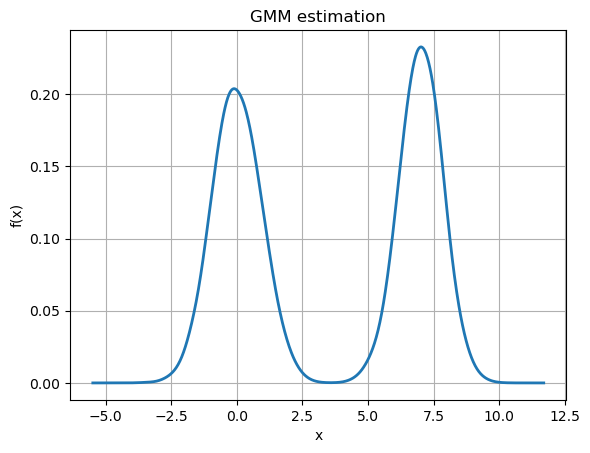

In [8]:
weights, means, variances, history = fit_gmm_1d(x, n_components=2)

pdf_em = sum(
    weights[m]
    * normal_pdf_1d(x_grid, means[m], variances[m])
    for m in range(len(weights))
)

plt.figure()
plt.plot(x_grid, pdf, lw=2)
plt.grid()
plt.title('GMM estimation')
plt.xlabel('x')
plt.ylabel('f(x)')

Scikit-learn provides a robust implementation through `GaussianMixture`:

C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Impossibile trovare il file specificato
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\WKS\anaconda3\envs\mtf2\lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\WKS\anaconda3\envs\mtf2\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\WKS\anaconda3\envs\mtf2\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\WKS\anaconda3\envs\mtf2\lib\subprocess.py", line 1436, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


Text(0, 0.5, 'f(x)')

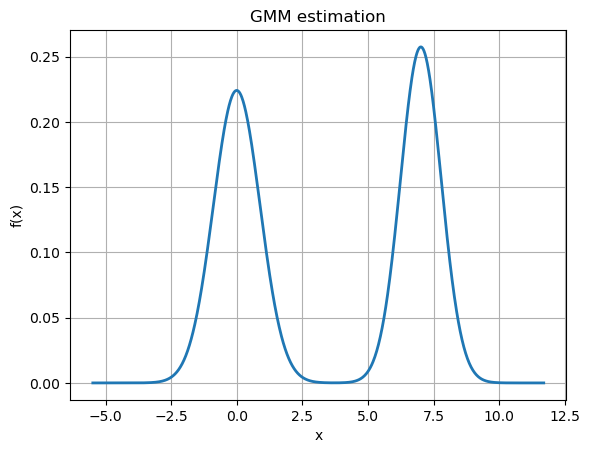

In [9]:
from sklearn.mixture import GaussianMixture

X = x.reshape(-1, 1)
x_grid_2d = x_grid.reshape(-1, 1)

gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    n_init=10,
    reg_covar=1e-6,
    random_state=0
)
gmm.fit(X)

log_density = gmm.score_samples(x_grid_2d)
pdf = np.exp(log_density)
responsibilities = gmm.predict_proba(X)

generated_samples, component_ids = gmm.sample(1000)

plt.figure()
plt.plot(x_grid, pdf, lw=2)
plt.grid()
plt.title('GMM estimation')
plt.xlabel('x')
plt.ylabel('f(x)')

When $M$ is unknown, candidate models can be compared using cross-validated log-likelihood or an information criterion, such as the **Akaike information criterion** (AIC) or **Bayesian information criterion** (BIC). For BIC, smaller values are preferred:

In [10]:
results = []

for n_components in range(1, 7):
    model = GaussianMixture(
        n_components=n_components,
        n_init=10,
        reg_covar=1e-6,
        random_state=0
    )
    model.fit(X)
    results.append({
        'components': n_components,
        'AIC': model.aic(X),
        'BIC': model.bic(X)
    })

best_result = min(results, key=lambda item: item['BIC'])
print(best_result)

{'components': 2, 'AIC': 38542.03594654302, 'BIC': 38578.08764840291}
